In [5]:
import pandas as pd
#Loading CSV Data
df = pd.read_csv("smart_home_energy_consumption_large.csv")
df.head()

,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
0,94,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2
1,435,Oven,0.23,20:11,2023-08-06,31.1,Summer,5
2,466,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3
3,496,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1
4,137,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5


In [6]:
#Filtering data
threshold = df["Energy Consumption (kWh)"].quantile(0.50)
high_energy_consumption_apps = df[df["Energy Consumption (kWh)"] > threshold]

print("\nHigh Energy Consuming Appliances:")
print(high_energy_consumption_apps[["Appliance Type", "Energy Consumption (kWh)"]])

#Filtering the data to only the top 10 most highest consuming energy appliances
print("\n --- \n")

top_10_consumption_apps = df.nlargest(10, "Energy Consumption (kWh)")
print("Top 10 Highest Energy Consuming Appliances:")
print(top_10_consumption_apps[["Appliance Type", "Energy Consumption (kWh)"]])


High Energy Consuming Appliances:
         Appliance Type  Energy Consumption (kWh)
3                Heater                      3.92
5      Air Conditioning                      4.68
7      Air Conditioning                      3.50
9             Microwave                      1.34
11           Dishwasher                      1.33
...                 ...                       ...
99990                TV                      1.57
99991            Heater                      2.10
99992   Washing Machine                      1.24
99993                TV                      1.31
99998  Air Conditioning                      2.69

[49755 rows x 2 columns]

 --- 

Top 10 Highest Energy Consuming Appliances:
         Appliance Type  Energy Consumption (kWh)
531              Heater                       5.0
1266             Heater                       5.0
2405             Heater                       5.0
2854             Heater                       5.0
4614             Heater              

In [19]:
#Creating a Set that showcases the amount of high energy consumping appliances
print
print("\n --- \n")
high_set = set(high_energy_consumption_apps["Appliance Type"])
print("Appliance types with highest energy consumption:", high_set)
print("Cardinality:", len(high_set))


 --- 

Appliance types with highest energy consumption: {'Washing Machine', 'Oven', 'Dishwasher', 'Lights', 'Microwave', 'Heater', 'TV', 'Computer', 'Air Conditioning'}
Cardinality: 9


In [28]:
#Create a Dictionary of Energy Consumption for a particular appliance
energy_consumption_dict = dict(zip(df["Appliance Type"], df["Energy Consumption (kWh)"]))
print(f"The energy consumption of your requested appliance is:, {energy_consumption_dict['Washing Machine']}")

The energy consumption of your requested appliance is:, 1.24


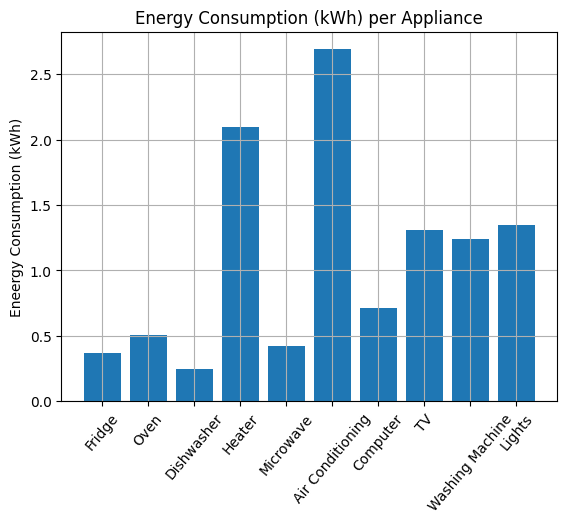

In [32]:
#Create a bar chart 
import matplotlib.pyplot as plt

plt.bar(energy_consumption_dict.keys(), energy_consumption_dict.values())
plt.xticks(rotation=50)
plt.title("Energy Consumption (kWh) per Appliance")
plt.ylabel("Eneergy Consumption (kWh)")
plt.grid(True)
plt.show()

In [7]:
#Save a filtered Subset
df = pd.read_csv("smart_home_energy_consumption_large.csv")
subset= df.nlargest(10,"Energy Consumption (kWh)" )
subset.to_csv("High_energy_consumption_appliances.csv", index=False)